## Calculate Habitat Complexity Index Using a Principal Component Analysis 

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

#### I. Import, Clean, and Define Habitat Metrics
Import the dataframe of xDEM-generated habitat metrics generated in the  [03_Zonal_Statistics](03_Zonal_Statistics.ipynb) notebook.

In [3]:
df = pd.read_csv('habitat_metrics_summary_wide.csv')
df

,Grid_Cell_ID,Full_Area,Area,MPA_Status,aspect_min,aspect_max,aspect_mean,aspect_std,aspect_median,curvature_min,...,terrain_ruggedness_index_min,terrain_ruggedness_index_max,terrain_ruggedness_index_mean,terrain_ruggedness_index_std,terrain_ruggedness_index_median,topographic_position_index_min,topographic_position_index_max,topographic_position_index_mean,topographic_position_index_std,topographic_position_index_median
0,AN01,Ano Nuevo,AN,REF,0.000608,359.999939,189.086755,104.148533,204.255234,-175.711914,...,0.014134,7.820934,0.927034,0.645765,0.776787,-1.815591,2.214877,-0.000039,0.169788,-0.011216
1,AN02,Ano Nuevo,AN,REF,0.000523,359.999756,185.132689,104.709714,200.048111,-158.436584,...,0.040059,8.464078,1.081520,0.635674,0.942224,-1.926841,1.956610,0.000311,0.189826,-0.009952
2,AN03,Ano Nuevo,AN,REF,0.000000,359.999542,189.599869,100.954922,215.612183,-109.372665,...,0.009995,8.280178,0.819195,0.746204,0.587218,-1.462498,1.740995,-0.000016,0.138957,-0.005646
3,AN04,Ano Nuevo,AN,REF,0.000000,359.999725,210.390805,98.236500,236.306763,-199.208252,...,0.000010,12.866380,0.688425,0.912303,0.379040,-2.200926,3.405399,-0.000156,0.160587,-0.001286
4,AN05,Ano Nuevo,AN,REF,0.000000,359.999817,207.752991,95.385900,223.670044,-101.696396,...,0.000000,7.459412,0.763163,0.961316,0.405691,-1.335721,1.534657,0.000054,0.170942,-0.001247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,SW15,Swamis,SW,REF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,SW16,Swamis,SW,REF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,SW17,Swamis,SW,REF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,SW18,Swamis,SW,REF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Remove locations that we will not use in our ultimate analysis from the dataframe. 

In [4]:
disqualified_areas = ['TD', 'PC', 'LB']
df_cleaned = df[~df['Area'].isin(disqualified_areas)]

Distinguish relevant habitat metrics from metadata, and remove instances in habitat data where no habtiat metrics were generated (in this case, due to mistmach between the extent of the DEM and the grid cells during zonal statistics). 

In [5]:
# Differentiate between columns associated with metadata and habitat metrics  
metadata_columns = ['Grid_Cell_ID', 'Area', 'Full_Area', 'MPA_Status']
complexity_metrics = ['slope_mean', 
                   'topographic_position_index_std', 
                   'profile_curvature_std',
                    'planform_curvature_std', 
                    'curvature_std',
                   'roughness_mean',
                   'rugosity_mean',
                   'terrain_ruggedness_index_mean',
                   'fractal_roughness_mean']

# Remove rows that have no data in metrics specified by 'complexity_metrics' list
complexity_df = df_cleaned[metadata_columns + complexity_metrics].dropna(subset=complexity_metrics, how='all')

### II. Calculate Principal Components of Selected Complexity Metrics
Create a data matrix containing the variables plotted above, and create a second matrix where each variable has been standardized by computing the z-scores. PCAs don't necessarily assume normality, so I am adding my raw, un-transformed values for each of the habitat metrics I want to include in my habitat complexity proxy metric. 

In [6]:
# Standardize the metrics before PCA
scaler = StandardScaler()
complexity_scaled = scaler.fit_transform(complexity_df[complexity_metrics])

Extract and print the loading of each of the principal components. 

In [7]:
# Run PCA and extract both PC1 and PC2
pca = PCA(n_components=2)
components = pca.fit_transform(complexity_scaled)

# Extract PC1 and PC2
pc1 = components[:, 0]
pc2 = components[:, 1]

# Print variance explained by each
print(f"Explained variance by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Explained variance by PC2: {pca.explained_variance_ratio_[1]:.2%}")


Explained variance by PC1: 84.82%
Explained variance by PC2: 11.60%


**Calculate and plot loadings of each variable for PC1 and PC2.**

In [8]:
# Create a DataFrame of loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2'],
                        index=complexity_metrics)

# Sort by absolute value of PC1 to see strongest contributors
pc1_loadings_sorted = loadings['PC1'].abs().sort_values(ascending=False)

# Combine sorted table for clarity
loadings_sorted = loadings.loc[pc1_loadings_sorted.index]

print(loadings_sorted)

                                     PC1       PC2
profile_curvature_std           0.357820 -0.053160
topographic_position_index_std  0.357462 -0.073363
curvature_std                   0.355406 -0.097965
terrain_ruggedness_index_mean   0.353786  0.139584
roughness_mean                  0.351394  0.163705
planform_curvature_std          0.348316 -0.148260
slope_mean                      0.346279  0.187617
rugosity_mean                   0.343107  0.155994
fractal_roughness_mean         -0.101363  0.924335


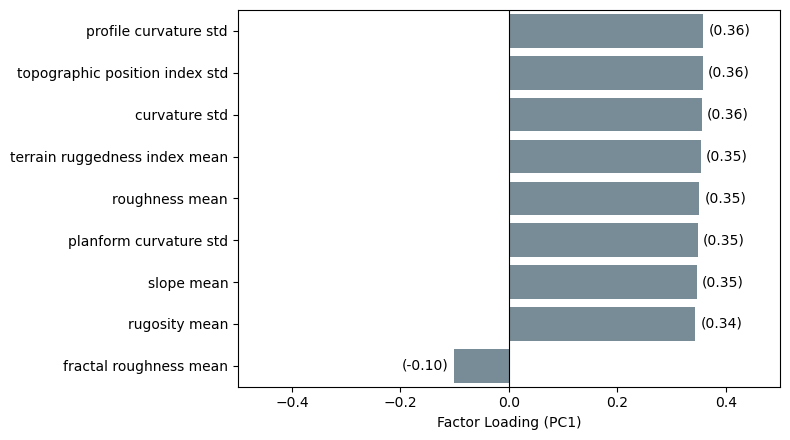

In [9]:
# Use loadings from your previous PCA
loadings_to_plot = loadings[['PC1']]  

# Sort by magnitude
loadings_to_plot = loadings_to_plot.reindex(loadings_to_plot['PC1'].abs().sort_values(ascending=False).index)

# Replace underscores in variable names for display
y_labels = [var.replace('_', ' ') for var in loadings_to_plot.index]

# Create horizontal bar plot
plt.figure(figsize=(8, len(loadings_to_plot)*0.5))
bars = sns.barplot(x='PC1', y=y_labels, data=loadings_to_plot, color = '#738D9C')

# Add vertical line at 0
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Factor Loading (PC1)')
plt.xlim([-0.5, 0.5])

# Annotate bars with loading values
for i, (value) in enumerate(loadings_to_plot['PC1']):
    bars.text(x=value + (0.01 if value > 0 else -0.01),  # small offset
              y=i, 
              s=f'({value:.2f})', 
              color='black', 
              va='center', 
              ha='left' if value > 0 else 'right')

plt.tight_layout()

output_path = f"WSN_Figures/PC1_factor_loading.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()


Build a new data frame with the complexity metrics we generated from the first and second principal component of our PCA. 

In [10]:
# Build a new dataset that contains the PC1 and PC2 values for each grid cell
pc_df = pd.DataFrame({'PC1': pc1, 'PC2': pc2, 'Area': complexity_df['Area'], 'MPA_Status': complexity_df['MPA_Status'], 'Grid_Cell_ID': complexity_df['Grid_Cell_ID']})

# Compute mean and SE per Area
area_means = pc_df.groupby('Area')[['PC1','PC2']].mean()
area_se = pc_df.groupby('Area')[['PC1','PC2']].sem()

In [11]:
pc_df

,PC1,PC2,Area,MPA_Status,Grid_Cell_ID
0,1.799775,-1.398461,AN,REF,AN01
1,2.581130,-1.201560,AN,REF,AN02
2,0.999237,-0.905982,AN,REF,AN03
3,1.083282,-1.377775,AN,REF,AN04
4,1.458276,-1.217885,AN,REF,AN05
...,...,...,...,...,...
343,5.168113,-0.109793,SP,REF,SP16
344,3.923427,0.506341,SP,REF,SP17
345,4.239567,0.869268,SP,REF,SP18
346,2.720328,-0.106113,SP,REF,SP19


### III. Plot the PCA and Vector Loadings

Plot the first and second principal components by CCFRP-sampled area to investigate spatial trends in the complexity metric we generated. Plot vector loadings of the habitat metrics that it is comprised of. 

Set up a color indexing system to map colors correctly onto PCA scatter and mean values for each area. 

In [21]:
import matplotlib.colors as mcolors

# Order of MPAs from south to north for labelling + coloring 
south_to_north = list(reversed(['LJ', 'CP', 'PB', 'BL', 'PL', 'AN', 'FN', 'BH', 'SP', 'CM']))


# Create color indices based on the order of south_to_north
area_to_index = {area: i for i, area in enumerate(south_to_north)}
color_indices = pc_df['Area'].map(area_to_index)

# Define consistent colormap normalization
norm = mcolors.Normalize(vmin=0, vmax=len(south_to_north) - 1)
cmap = plt.cm.YlOrBr_r


Plot the PCA and vector loadings. 

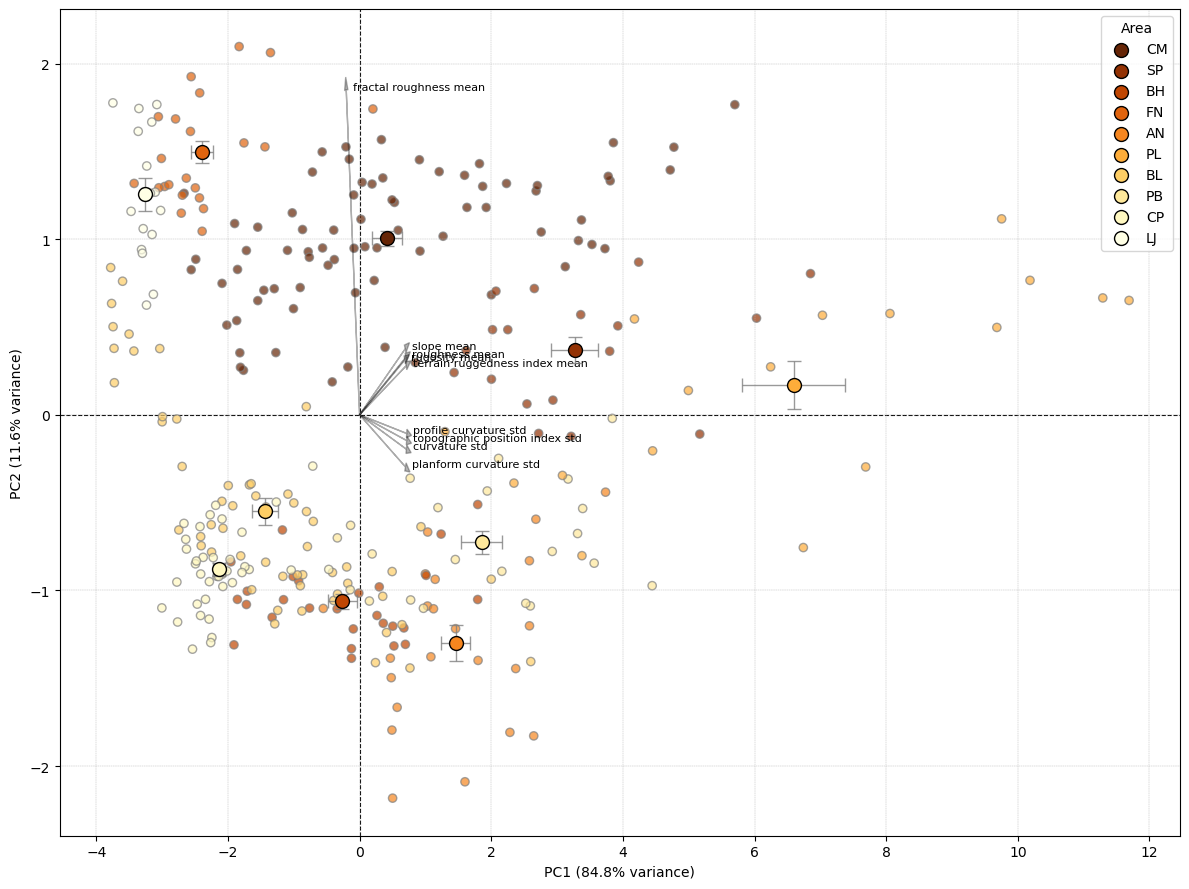

In [29]:
loadings = pca.components_.T[:, :2]

plt.figure(figsize=(12, 9))

plt.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=0)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', zorder=0)

# Scatter points colored by Area
scatter = plt.scatter(pc1, pc2, c=color_indices, cmap=cmap, norm=norm, alpha=0.7, edgecolor='grey')

for i, area_name in enumerate(south_to_north):
    x_mean = area_means.loc[area_name, 'PC1']
    y_mean = area_means.loc[area_name, 'PC2']
    x_se = area_se.loc[area_name, 'PC1']
    y_se = area_se.loc[area_name, 'PC2']
    
    color = cmap(norm(i))
    
    # Grey error bars for clarity, no label
    plt.errorbar(
        x_mean, y_mean,
        xerr=x_se, yerr=y_se,
        fmt='none',
        ecolor='grey',
        elinewidth=1,
        capsize=5,
        alpha=0.8,
        zorder=4
    )

    # Colored mean point *with label for legend*
    plt.scatter(
        x_mean, y_mean,
        color=color,
        edgecolor='black',
        s=100,
        zorder=5,
        label=area_name
    )


# Add vectors for each metric
vector_scaling = 2
for i, metric in enumerate(complexity_metrics):
    x, y = loadings[i,0]*vector_scaling, loadings[i,1]*vector_scaling
    plt.arrow(0, 0, x, y, color='black', alpha=0.3, head_width=0.05)
    plt.text(x+.1, y*1, metric.replace("_"," "), fontsize=8, color='black')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')


plt.legend(title='Area', loc='upper right')
plt.grid(linewidth=0.3, linestyle = '--')
plt.tight_layout()

output_path = f"WSN_Figures/complexity_PCA_vectors_LABELLED.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

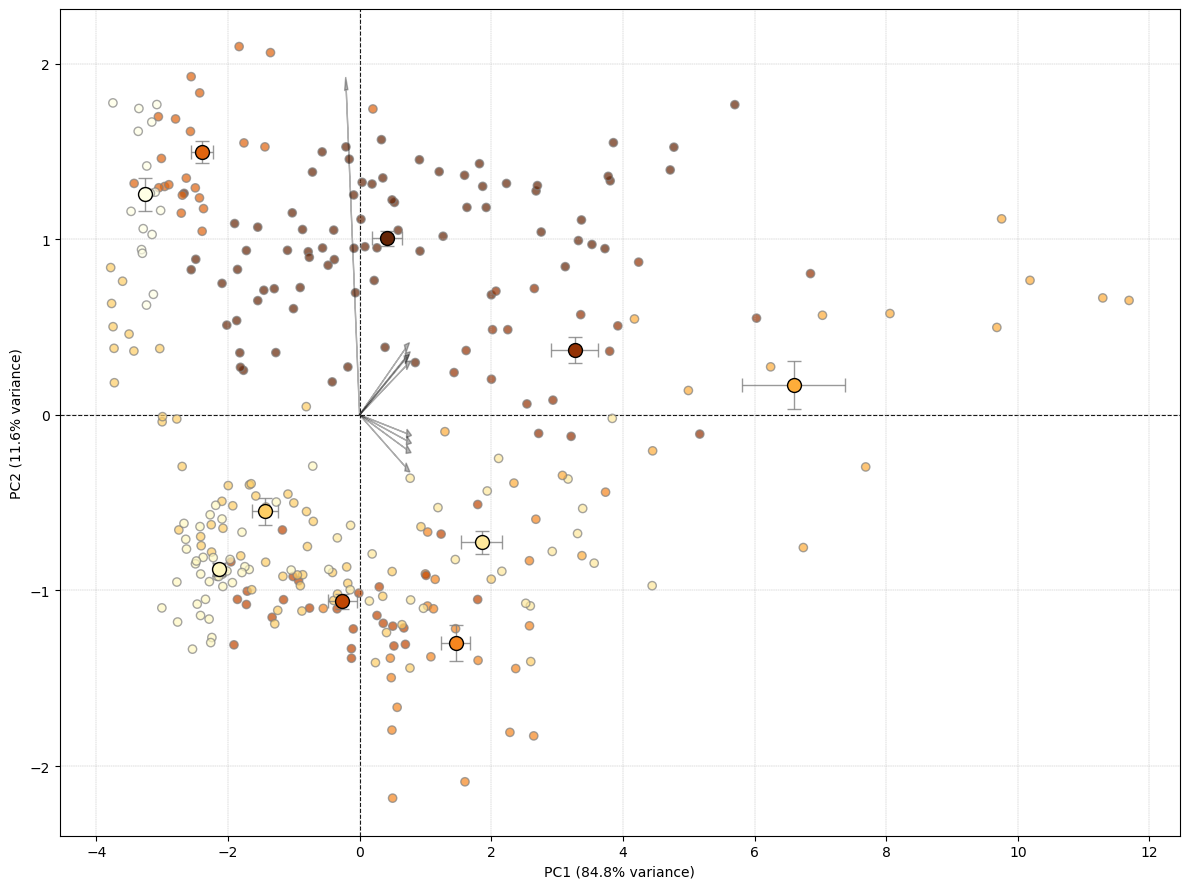

In [30]:
loadings = pca.components_.T[:, :2]

plt.figure(figsize=(12, 9))

plt.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=0)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', zorder=0)

# Scatter points colored by Area
scatter = plt.scatter(pc1, pc2, c=color_indices, cmap=cmap, norm=norm, alpha=0.7, edgecolor='grey')

for i, area_name in enumerate(south_to_north):
    x_mean = area_means.loc[area_name, 'PC1']
    y_mean = area_means.loc[area_name, 'PC2']
    x_se = area_se.loc[area_name, 'PC1']
    y_se = area_se.loc[area_name, 'PC2']
    
    color = cmap(norm(i))
    
    # Grey error bars for clarity, no label
    plt.errorbar(
        x_mean, y_mean,
        xerr=x_se, yerr=y_se,
        fmt='none',
        ecolor='grey',
        elinewidth=1,
        capsize=5,
        alpha=0.8,
        zorder=4
    )

    # Colored mean point *with label for legend*
    plt.scatter(
        x_mean, y_mean,
        color=color,
        edgecolor='black',
        s=100,
        zorder=5,
        label=area_name
    )

# Add vectors for each metric
vector_scaling = 2
for i, metric in enumerate(complexity_metrics):
    x, y = loadings[i,0]*vector_scaling, loadings[i,1]*vector_scaling
    plt.arrow(0, 0, x, y, color='black', alpha=0.3, head_width=0.05)
    plt.text(x+.1, y*1, metric.replace("_"," "), fontsize=8, color='black')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

# Legend and grid
leg = plt.legend(title='Area', loc='upper right')
plt.grid(linewidth=0.3, linestyle='--')
plt.tight_layout()

# --- Save version with labels ---
output_path_labeled = "WSN_Figures/complexity_PCA_vectors_LABELLED.png"
plt.savefig(output_path_labeled, dpi=300, bbox_inches='tight')

# --- Remove legend and text labels before saving unlabeled version ---
leg.remove()  # remove legend

# remove metric text labels
for txt in plt.gca().texts:
    txt.remove()

# Save version without labels
output_path_unlabeled = "WSN_Figures/complexity_PCA_vectors_UNLABELLED.png"
plt.savefig(output_path_unlabeled, dpi=300, bbox_inches='tight')

plt.show()


#### IV. Clean and Export the Complexity Data

In [14]:
# Create the final DataFrame with both PC1 and PC2
df_complexity = pc_df.copy()
df_complexity = df_complexity.rename(columns= {'PC1': 'habitat_complexity_PC1', 'PC2': 'habitat_complexity_PC2'})

For future analyses, we need to shift our PC1 complexity metric that we are using as a proxy for complexity so that all the values are above zero. This will also be useful when we are looking into differences in complexity between MPA and REF sites in later analyses. 


In [15]:
min_val = df_complexity['habitat_complexity_PC1'].min()

shift = abs(min_val) + 0.001  # small buffer so minimum > 0
df_complexity['PC1_shifted'] = df_complexity['habitat_complexity_PC1'] + shift

Let's check out whether our data look normal. We can explore a variety of transformations, but I am opting for a square root transformation because a log transformation is too aggressive. 

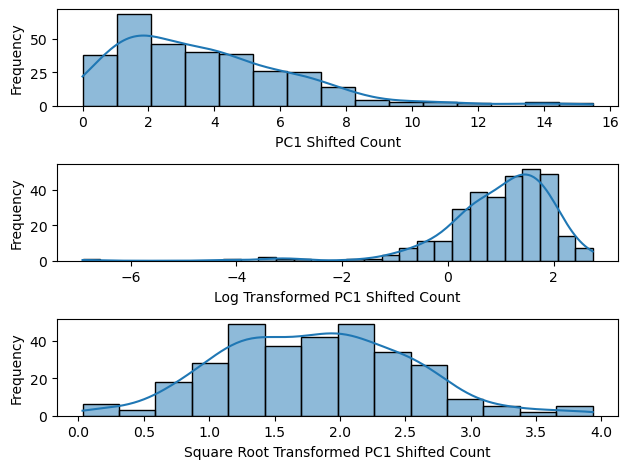

In [16]:
plt.figure()

plt.subplot(3, 1, 1)
sns.histplot(df_complexity['PC1_shifted'], kde=True)
plt.ylabel('Frequency')
plt.xlabel('PC1 Shifted Count')

plt.subplot(3, 1, 2)
sns.histplot(np.log(df_complexity['PC1_shifted']), kde=True)
plt.ylabel('Frequency')
plt.xlabel('Log Transformed PC1 Shifted Count')

plt.subplot(3, 1, 3)
sns.histplot(np.sqrt(df_complexity['PC1_shifted']), kde=True)
plt.ylabel('Frequency')
plt.xlabel('Square Root Transformed PC1 Shifted Count')

plt.tight_layout()
plt.show()

Perform a square root transformation on the shifted data and add it to the dataframe. 

Then, subtract the overall mean of PC1_shifted across my entire study site to center my data. For the purposes of this model, this will reflect whether an area or site is above or below the mean complexity across the entire coast rather than arbitrarily selecting the first alphabetic area as a refrence point. 

In [17]:
# Square root transform the data
df_complexity['PC1_sqrt'] = np.sqrt(df_complexity['PC1_shifted'])

# Center the data around the regional mean (e.g. complexity value within a grid cell - mean complexity of entire dataset) 
df_complexity['PC1_centered'] = df_complexity['PC1_sqrt'] - df_complexity['PC1_sqrt'].mean()

# Calcualte a z score of complexity across the entire dataset 
df_complexity['PC1_zscore'] = (
    (df_complexity['PC1_sqrt'] - df_complexity['PC1_sqrt'].mean()) 
    / df_complexity['PC1_sqrt'].std()
)
df_complexity

,habitat_complexity_PC1,habitat_complexity_PC2,Area,MPA_Status,Grid_Cell_ID,PC1_shifted,PC1_sqrt,PC1_centered,PC1_zscore
0,1.799775,-1.398461,AN,REF,AN01,5.581872,2.362599,0.552342,0.775962
1,2.581130,-1.201560,AN,REF,AN02,6.363227,2.522544,0.712287,1.000662
2,0.999237,-0.905982,AN,REF,AN03,4.781335,2.186626,0.376370,0.528746
3,1.083282,-1.377775,AN,REF,AN04,4.865380,2.205761,0.395504,0.555627
4,1.458276,-1.217885,AN,REF,AN05,5.240374,2.289186,0.478930,0.672828
...,...,...,...,...,...,...,...,...,...
343,5.168113,-0.109793,SP,REF,SP16,8.950210,2.991690,1.181434,1.659745
344,3.923427,0.506341,SP,REF,SP17,7.705524,2.775883,0.965626,1.356566
345,4.239567,0.869268,SP,REF,SP18,8.021664,2.832254,1.021998,1.435760
346,2.720328,-0.106113,SP,REF,SP19,6.502425,2.549985,0.739729,1.039213


Merge the newly generated dataframe with the habitat complexity index with the original habitat metric dataframe so that all the data are together. 

In [18]:
# Export the dataset as a .csv
output_path = "habitat_complexity_summary.csv"
df_complexity.to_csv(output_path, index=False)